# PyTorch Model Visualization


In [1]:
import torch
import torch.nn as nn

In [2]:
num_features = 50
num_output = 3

# Define the model
model = nn.Sequential(
    nn.Linear(num_features, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, num_output),
)

### Model Inspection

To understand the architecture of a PyTorch model, we can inspect its parameters. The `model.parameters()` method returns an iterator over all the parameters (weights and biases) of the model. We can use this to count the total number of parameters, as well as how many of them are trainable (i.e., require gradients).


In [7]:
list(range(10))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [14]:
# Generator object
print(model.parameters())

# Extracting the first parameter tensor from the generator object.
params = list(model.parameters())
param = params[0]
print(param)

# shapes: the shape of the parameter tensor,
print(f"param.shape: {param.shape}")

# numel: the total number of elements in the parameter tensor,
print(f"param.numel(): {param.numel()}")

# requires_grad: whether the parameter is trainable (i.e., whether it will be updated during training). You can set it to `False` if you want to freeze the parameter during training.
print(f"param.requires_grad: {param.requires_grad}")

<generator object Module.parameters at 0x000001761CEC5000>
Parameter containing:
tensor([[-0.0498, -0.0170, -0.1191,  ...,  0.0038, -0.0408,  0.1015],
        [ 0.0108, -0.1101,  0.0996,  ...,  0.0978, -0.1194,  0.1137],
        [-0.1209, -0.0394, -0.1151,  ...,  0.1364, -0.0419,  0.0603],
        ...,
        [-0.0853,  0.1120, -0.0188,  ..., -0.0594,  0.1149, -0.0242],
        [ 0.1046,  0.0126,  0.0355,  ...,  0.0382,  0.1150,  0.0846],
        [-0.1181, -0.0093, -0.1057,  ..., -0.0308,  0.0616, -0.0406]],
       requires_grad=True)
param.shape: torch.Size([24, 50])
param.numel(): 1200
param.requires_grad: True


In [20]:
# Generator object
print(model.parameters())

# Extracting the first parameter tensor from the generator object.
params = list(model.parameters())
param = params[0]
print(param)

# shapes: the shape of the parameter tensor,
print(f"param.shape: {param.shape}")

# numel: the total number of elements in the parameter tensor,
print(f"param.numel(): {param.numel()}")

# requires_grad: whether the parameter is trainable (i.e., whether it will be updated during training). You can set it to `False` if you want to freeze the parameter during training.
print(f"param.requires_grad: {param.requires_grad}")

<generator object Module.parameters at 0x000001761CE94900>
Parameter containing:
tensor([[-0.0498, -0.0170, -0.1191,  ...,  0.0038, -0.0408,  0.1015],
        [ 0.0108, -0.1101,  0.0996,  ...,  0.0978, -0.1194,  0.1137],
        [-0.1209, -0.0394, -0.1151,  ...,  0.1364, -0.0419,  0.0603],
        ...,
        [-0.0853,  0.1120, -0.0188,  ..., -0.0594,  0.1149, -0.0242],
        [ 0.1046,  0.0126,  0.0355,  ...,  0.0382,  0.1150,  0.0846],
        [-0.1181, -0.0093, -0.1057,  ..., -0.0308,  0.0616, -0.0406]],
       requires_grad=True)
param.shape: torch.Size([24, 50])
param.numel(): 1200
param.requires_grad: True


In [21]:
def count_parameters(model):
    # Count total and trainable parameters in the model
    total_params = sum(p.numel() for p in model.parameters())
    # Count only trainable parameters (those that require gradients)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Print the results
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}\n")
    print("Parameters by layer:")

    # Print the number of parameters for each layer
    for name, param in model.named_parameters():
        print(f"\t{name}: {param.numel():,}")


count_parameters(model)

Total parameters: 1,623
Trainable parameters: 1,623

Parameters by layer:
	0.weight: 1,200
	0.bias: 24
	2.weight: 288
	2.bias: 12
	4.weight: 72
	4.bias: 6
	6.weight: 18
	6.bias: 3


### Torchsummary


In [23]:
from torchinfo import summary

batch_size = 100
input_size = (batch_size, num_features,)
summary(model, input_size=input_size)

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [100, 3]                  --
├─Linear: 1-1                            [100, 24]                 1,224
├─ReLU: 1-2                              [100, 24]                 --
├─Linear: 1-3                            [100, 12]                 300
├─ReLU: 1-4                              [100, 12]                 --
├─Linear: 1-5                            [100, 6]                  78
├─ReLU: 1-6                              [100, 6]                  --
├─Linear: 1-7                            [100, 3]                  21
Total params: 1,623
Trainable params: 1,623
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.16
Input size (MB): 0.02
Forward/backward pass size (MB): 0.04
Params size (MB): 0.01
Estimated Total Size (MB): 0.06

### Torchviz


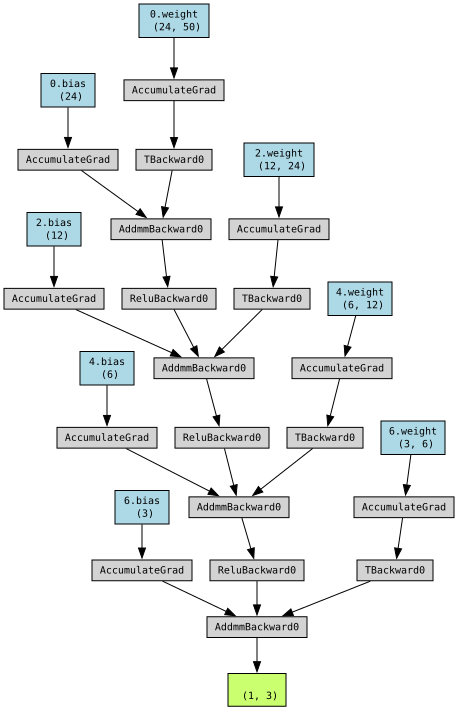

In [25]:
from torchviz import make_dot

X_sample = torch.rand(1, num_features)  # (batch_size, num_features)
Y_sample = model(X_sample)
make_dot(Y_sample, params=dict(model.named_parameters()))

### Tensorboard


*Run into problem with setuptools where it cannot find `pkg_resources` when running `tensorboard` command.  Need to investigate further.*

- Type in your command prompt
    - `tensorboard --logdir=src/T01_basic_pytorch/runs`
- Visit http://localhost:6006


In [26]:
from torch.utils.tensorboard import SummaryWriter

# writer = SummaryWriter("runs/model_visualization")
# writer.add_graph(model, X_sample)
# writer.close()

### App

- Visit https://netron.app/
- Load the saved model.


In [27]:
class MyComplicatedMLP(nn.Module):
    def __init__(self, input_dim=50, hidden_dim=64, output_dim=1):
        super(MyComplicatedMLP, self).__init__()

        # Linear layers for splitting
        self.fc_first = nn.Linear(25, 32)
        self.fc_latter = nn.Linear(25, 32)

        # Activation functions
        self.act_first = nn.ReLU()
        self.act_latter = nn.Sigmoid()

        # Combine and further processing
        self.fc_combined = nn.Linear(64, hidden_dim)
        self.act_combined = nn.ReLU()
        self.fc_output = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Split input: x[:, :25] and x[:, 25:]
        x_first = self.act_first(self.fc_first(x[:, :25]))
        x_latter = self.act_latter(self.fc_latter(x[:, 25:]))

        # Concatenate
        x_combined = torch.cat([x_first, x_latter], dim=1)
        x = self.act_combined(self.fc_combined(x_combined))
        out = self.fc_output(x)
        return out
    
model = MyComplicatedMLP()

In [28]:
torch.save(model, "./my_pytorch_model.pt")